In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import numpy as np 
import itertools
import scipy 
import math
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)
pi = torch.tensor(np.pi,dtype=torch.float64)

from utils import PiecewiseGQ2D_weights_points, SquareMesh2D_points
from utils import s2_uniform_grid_init
from utils import output_convergence_order_l2
from utils import plot_err_convergence

In [ ]:
class PouShallowReLUkNetwork:
    def __init__(
        self, ws, bs, quad_pts, quad_wei, k=1, l=1, sigma=0.01, m1=1, m2=1):
        
        self.n = ws.shape[0]
        self.k = k
        self.l = l
        self.sigma = sigma
        self.m1 = m1 
        self.m2 = m2
        self.quad_pts = quad_pts 
        self.quad_wei = quad_wei
        cntrs, rng = self.pou_init()
        self.cntrs, self.rng = cntrs, rng

        self.J = self.cntrs.shape[0]
        self.W = ws.unsqueeze(1).repeat(1,self.J,1)   # [C, J, d]
        self.b = bs.unsqueeze(1).repeat(1,self.J)     # [C, J]
    
    def map_unit(self, x):
        '''
        Inputs:
            x : (N, D)
            cntrs: (J, D)
            rng : float
        Returns:
            x_ : (N, J, D)
        '''
        x_ = (x.unsqueeze(1) - self.cntrs.unsqueeze(0) + self.rng)/(2 * self.rng)
        return x_
    
    def pou_init(self):
        rng = 1 / 2**(self.l)
        cntr_1d = torch.linspace(0, 1, 2**(self.l-1)+1).reshape(-1, 1)
        grid = list(itertools.product(cntr_1d, repeat=2)) # 2 for 2D input
        cntrs = torch.tensor(grid)
        return cntrs, rng

    def pou_feat(self, x):
        '''
        Inputs:
            x : (N, D) tensor
            cntrs : (J, D) tensor 
            rng : scalar (float or tensor)
            sigma : scalar (float or tensor)
        Returns:
            (N, J) tensor
        '''
        def phi(z):
            return 1 / (1 + torch.exp(-z))

        # Expand dimensions for broadcasting: (N,1,D) - (1,M,D) → (N,M,D)
        a = cntrs.unsqueeze(0) - self.rng
        b = cntrs.unsqueeze(0) + self.rng
        x_exp = x.unsqueeze(1)  # (N,1,D)

        # Apply PoU formula over each dimension
        vals = phi((x_exp - a) / self.sigma) * phi((b - x_exp) / self.sigma)

        # Product over D → (N,M)
        return vals.prod(dim=2, keepdim=True)

    def feat_extract(self, x):
        return F.relu(x @ self.W.t() + self.b) ** self.k

    def target(self, x):
        z = torch.sin(self.m1 * pi*x[:,0:1])*torch.sin(self.m2 * pi*x[:,1:2])
        return z 

    def assemble(self):
        A = self.feat_extract(self.quad_pts) * self.quad_wei
        b = self.target(self.quad_pts) * self.quad_wei
        return A, b

    def solve(self):
        A, b = self.assemble()

        c = 100.0 
        for i in range(len(A)):
            max_a = abs(A[i,:]).max()
            max_b = A[i,:].max()
            if max_a != max_b: 
                ratio = -c/max_a
                A[i,:] = A[i,:]*ratio
                b[i] = b[i]*ratio
            else: 
                ratio = c/max_a
                A[i,:] = A[i,:]*ratio
                b[i] = b[i]*ratio
        alpha = scipy.linalg.lstsq(A.numpy(),b.numpy())[0]
        self.alpha = torch.tensor(alpha)
        
    def forward(self, x):
        return self.feat_extract(x) @ self.alpha
    
    def eval(self, x):
        y_ref = self.target(x)
        y_pred = self.forward(x)
        rel_errl2 = (y_pred - y_ref).norm() / y_ref.norm()
        return rel_errl2.item()

In [22]:
k = 1
m1 = 1
m2 = 1
quad_wei, quad_pts = PiecewiseGQ2D_weights_points(50, 3, bl = [0,0], ur = [1,1])
x_test = SquareMesh2D_points(0,1,150)

In [23]:
ws, bs = s2_uniform_grid_init(32, k=1)
model = PouShallowReLUkNetwork(
    ws, bs, quad_pts, quad_wei,k=1, m1=2, m2=m2)

In [4]:
k = 1
m1 = 1
m2 = 1
quad_wei, quad_pts = PiecewiseGQ2D_weights_points(50, 3, bl = [0,0], ur = [1,1])
neuron_num_arr= np.array([2**i for i in range(6,12)]) 
neuron_arr = []
rel_errl2_arr = []
for i, n in enumerate(neuron_num_arr):
    ws, bs = s2_uniform_grid_init(n, k=k)
    model = ShallowReLUkNetwork(
        ws, bs, quad_pts, quad_wei,k=k, m1=2, m2=m2)
    model.solve()
    rel_errl2 = model.eval(x_test)
    neuron_arr.append(model.n)
    rel_errl2_arr.append(rel_errl2)
    print('num neuron : {:} - rel l2 : {:.4e}'.format(model.n, rel_errl2))
title = "L2 fitting. ReLU$^{}$. $\sin(m_1\pi x_1) \sin(m_2\pi x_2)$, $m_1,m_2 = {}, {}$".format(k, m1, m2)

num neuron : 31 - rel l2 : 1.6588e-01
num neuron : 57 - rel l2 : 7.7565e-02
num neuron : 113 - rel l2 : 3.8335e-02
num neuron : 227 - rel l2 : 1.5245e-02
num neuron : 445 - rel l2 : 7.0111e-03
num neuron : 897 - rel l2 : 2.7220e-03


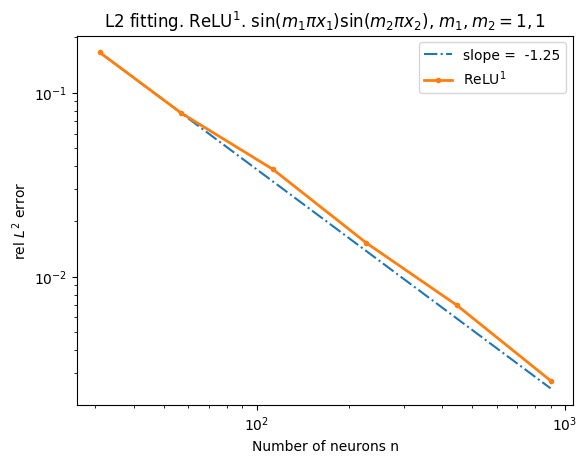

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
31 		 & 1.659e-01 &		 *  \\ \hline  

57 		 &  7.757e-02 &  		 1.25  \\ \hline  

113 		 &  3.833e-02 &  		 1.03  \\ \hline  

227 		 &  1.525e-02 &  		 1.32  \\ \hline  

445 		 &  7.011e-03 &  		 1.15  \\ \hline  

897 		 &  2.722e-03 &  		 1.35  \\ \hline  



In [5]:
plot_err_convergence(1,2,torch.tensor(neuron_arr), rel_errl2_arr,title)
output_convergence_order_l2(torch.tensor(neuron_arr), rel_errl2_arr)

In [15]:
def pou_init(l=1, d=1):
    '''
    Inputs:
        l : int subdomain level, 
            if l = 1, 
                2 subdomains on each axis
            if l = 2,
                3 subdomains on each axis 
            if l = 3,
                5 subdomains on each axis
        d : int input dim
    Returns:
        cntrs : (J, D), J = (2^(l-1) + 1)^2,
            if l = 1,
                d = 1, J = 2
                d = 2, J = 4
            if l = 2,
                d = 1, J = 3
                d = 2, J = 9
            if l = 3,
                d = 1, J = 5
                d = 2, J = 25
        rng : float, subdomain range
    '''
    rng = 1 / 2**(l)
    cntr_1d = torch.linspace(0, 1, 2**(l-1)+1).reshape(-1, 1)
    grid = list(itertools.product(cntr_1d, repeat=d))
    cntrs = torch.tensor(grid)
    return cntrs, rng